## Pneumonia Detection Using CNN in Python

## Project Objective 

Build a deep learning model using Convolutional Neural Networks (CNN) for medical image classification.

Preprocess and augment chest X-ray images to improve model generalization.

Train and evaluate the model using performance metrics such as Accuracy, Precision, Recall, and F1-score.

Develop a system that assists in early detection of pneumonia from X-ray images.

## Importing Libraries

The libraries we will using are : 

Pandas- 
The pandas library is a popular open-source data manipulation and analysis tool in Python. It provides a data structure called a DataFrame, which is similar to a spreadsheet or a SQL table, and allows for easy manipulation and analysis of data.

Numpy-
NumPy is a popular open-source library in Python for scientific computing, specifically for working with numerical data. It provides tools for working with large, multi-dimensional arrays and matrices, and offers a wide range of mathematical functions for performing operations on these arrays.

Matplotlib- 
It is a popular open-source data visualization library in Python. It provides a range of tools for creating high-quality visualizations of data, including line plots, scatter plots, bar plots, histograms, and more.

TensorFlow-
TensorFlow is a popular open-source library in Python for building and training machine learning models. It was developed by Google and is widely used in both academia and industry for a variety of applications, including image and speech recognition, natural language processing, and recommendation systems.

In [1]:
import matplotlib.pyplot as plt
import tensorflow as tf
import pandas as pd
import numpy as np
  
import warnings
warnings.filterwarnings('ignore')
  
from tensorflow import keras
from keras import layers
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Activation, Dropout, Flatten, Dense
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.utils import image_dataset_from_directory
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img
from tensorflow.keras.preprocessing import image_dataset_from_directory
  
import os
import matplotlib.image as mpimg

## Importing Dataset 
To run the notebook in the local system. The dataset can be downloaded from [ https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia ]. The dataset is in the format of a zip file. So to import and then unzip it, by running the below code. 

In [2]:
# Dataset Link- https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia
import zipfile

zip_path = r"C:\Users\ASUS\Downloads\archive (8).zip"

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall("chest_xray_data")

In [3]:
import os
os.path.exists(zip_path)

True

In [4]:
import os
os.listdir("chest_xray_data")

['chest_xray']

In [5]:
os.listdir("chest_xray_data/chest_xray")

['chest_xray', 'test', 'train', 'val', '__MACOSX']

## Read the image dataset
In this section, we will try to understand visualize some images which have been provided to us to build the classifier for each class.

Let's load the training image

In [6]:
import os

path = "chest_xray_data/chest_xray/train"
classes = os.listdir(path)
print(classes)

['NORMAL', 'PNEUMONIA']


This shows that, there are two classes that we have here i.e. Normal and Pneumonia.

In [7]:
import os

PNEUMONIA_dir = os.path.join(path, "PNEUMONIA")
NORMAL_dir = os.path.join(path, "NORMAL")

pneumonia_names = os.listdir(PNEUMONIA_dir)
normal_names = os.listdir(NORMAL_dir)

print("There are", len(pneumonia_names), 
      "images of pneumonia infected in training dataset")
print("There are", len(normal_names), 
      "normal images in training dataset")

There are 3875 images of pneumonia infected in training dataset
There are 1341 normal images in training dataset


Plot the Pneumonia infected Chest X-ray images

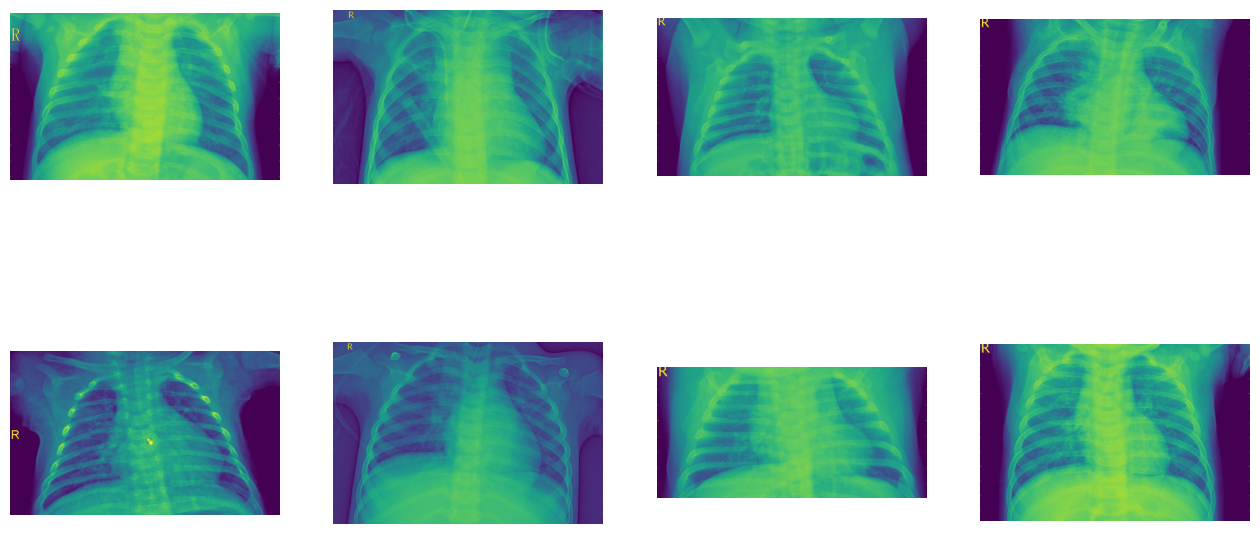

In [8]:
# Set the figure size
fig = plt.gcf()
fig.set_size_inches(16, 8)

# Select the starting index for the images to display
pic_index = 210

# Create lists of the file paths for the 16 images to display
pneumonia_images = [os.path.join(PNEUMONIA_dir, fname)
                    for fname in pneumonia_names[pic_index-8:pic_index]]
# Loop through the image paths and display each image in a subplot
for i, img_path in enumerate(pneumonia_images):
    sp = plt.subplot(2, 4, i+1)
    sp.axis('Off')

    # Read in the image using Matplotlib's imread() function
    img = mpimg.imread(img_path)
    plt.imshow(img)

# Display the plot with the 16 images in a 4x4
plt.show()


Plot the Normal Chest X-ray images



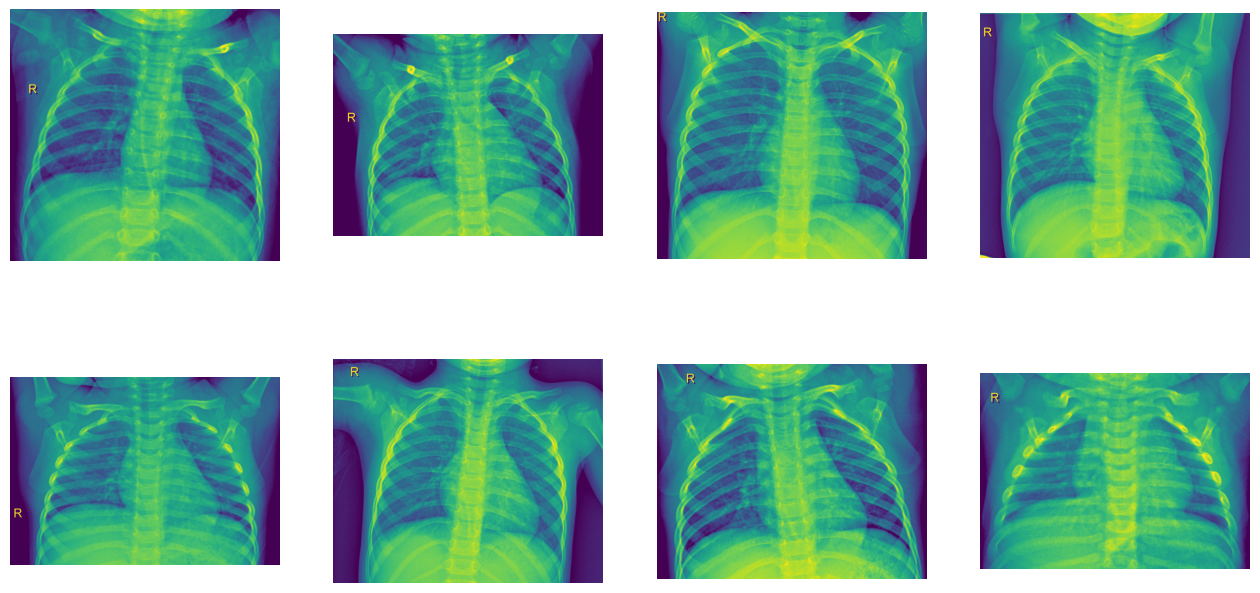

In [9]:
# Set the figure size
fig = plt.gcf()
fig.set_size_inches(16, 8)

# Select the starting index for the images to display
pic_index = 210

# Create lists of the file paths for the 16 images to display
normal_images = [os.path.join(NORMAL_dir, fname)
              for fname in normal_names[pic_index-8:pic_index]]
# Loop through the image paths and display each image in a subplot
for i, img_path in enumerate(normal_images):
    sp = plt.subplot(2, 4, i+1)
    sp.axis('Off')

    # Read in the image using Matplotlib's imread() function
    img = mpimg.imread(img_path)
    plt.imshow(img)

# Display the plot with the 16 images in a 4x4 grid
plt.show()

## Data Preparation for Training
In this section, we will classify the dataset into train,test and validation format.

In [10]:
from tensorflow import keras

Train = keras.utils.image_dataset_from_directory(
    directory="chest_xray_data/chest_xray/train",
    labels="inferred",
    label_mode="categorical",
    batch_size=32,
    image_size=(256, 256)
)

Test = keras.utils.image_dataset_from_directory(
    directory="chest_xray_data/chest_xray/test",
    labels="inferred",
    label_mode="categorical",
    batch_size=32,
    image_size=(256, 256)
)

Validation = keras.utils.image_dataset_from_directory(
    directory="chest_xray_data/chest_xray/val",
    labels="inferred",
    label_mode="categorical",
    batch_size=32,
    image_size=(256, 256)
)

Found 5216 files belonging to 2 classes.
Found 624 files belonging to 2 classes.
Found 16 files belonging to 2 classes.


## Model Architecture
The model architecture can be described as follows:

Input layer: Conv2D layer with 32 filters, 3x3 kernel size, 'relu' activation function, and input shape of (256, 256, 3)

MaxPooling2D layer with 2x2 pool size

Conv2D layer with 64 filters, 3x3 kernel size, 'relu' activation function

MaxPooling2D layer with 2x2 pool size

Conv2D layer with 64 filters, 3x3 kernel size, 'relu' activation function

MaxPooling2D layer with 2x2 pool size

Conv2D layer with 64 filters, 3x3 kernel size, 'relu' activation function

MaxPooling2D layer with 2x2 pool size

Flatten layer

Dense layer with 512 neurons, 'relu' activation function

BatchNormalization layer

Dense layer with 512 neurons, 'relu' activation function

Dropout layer with a rate of 0.1

BatchNormalization layer

Dense layer with 512 neurons, 'relu' activation function

Dropout layer with a rate of 0.2

BatchNormalization layer

Dense layer with 512 neurons, 'relu' activation function

Dropout layer with a rate of 0.2

BatchNormalization layer

Output layer: Dense layer with 2 neurons and 'sigmoid' activation function, representing the probabilities of the two classes (pneumonia or normal)

## In summary our model has : 

Four Convolutional Layers followed by MaxPooling Layers.
Then One Flatten layer to receive and flatten the output of the convolutional layer.
Then we will have three fully connected layers followed by the output of the flattened layer.
We have included some BatchNormalization layers to enable stable and fast training and a Dropout layer before the final layer to avoid any possibility of overfitting.
The final layer is the output layer which has the activation function sigmoid to classify the results into two classes(i,e Normal or Pneumonia).

In [11]:
model = tf.keras.models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(256, 256, 3)),
    layers.MaxPooling2D(2, 2),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),

    layers.Flatten(),
    layers.Dense(512, activation='relu'),
    layers.BatchNormalization(),
    layers.Dense(512, activation='relu'),
    layers.Dropout(0.1),
    layers.BatchNormalization(),
    layers.Dense(512, activation='relu'),
    layers.Dropout(0.2),
    layers.BatchNormalization(),
    layers.Dense(512, activation='relu'),
    layers.Dropout(0.2),
    layers.BatchNormalization(),
    layers.Dense(2, activation='sigmoid')
])

In [12]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 254, 254, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 127, 127, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 125, 125, 64)        │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 62, 62, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 60, 60, 64)          │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 30, 30, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 28, 28, 64)          │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 14, 14, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 12544)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 512)                 │       6,423,040 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 512)                 │           2,048 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 512)                 │         262,656 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 512)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 512)                 │           2,048 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 512)                 │         262,656 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 512)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 512)                 │           2,048 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 512)                 │         262,656 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 512)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_3                │ (None, 512)                 │           2,0

 Total params: 7,313,474 (27.90 MB)

 Trainable params: 7,309,378 (27.88 MB)

 Non-trainable params: 4,096 (16.00 KB)

The input image we have taken initially resized into 256 X 256. And later it transformed into the binary classification value

## Plot the model architecture:

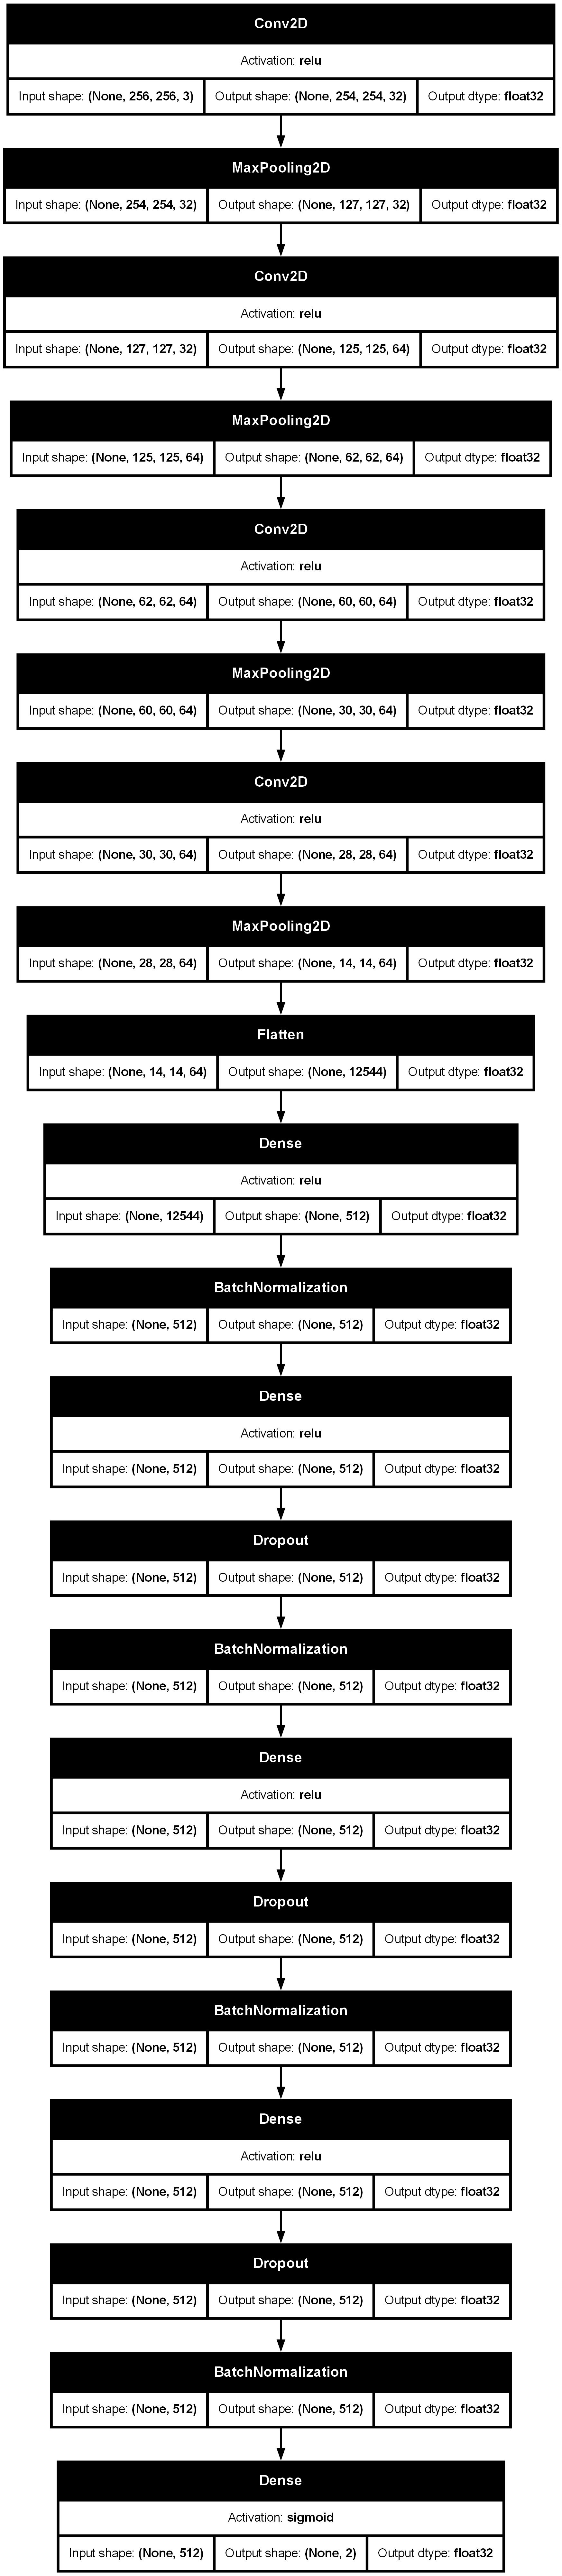

In [13]:
# Plot the keras model
keras.utils.plot_model(
    model,
    # show the shapes of the input/output tensors of each layer
    show_shapes=True,
    # show the data types of the input/output tensors of each layer
    show_dtype=True,
    # show the activations of each layer in the output graph
    show_layer_activations=True
)

In [15]:
pip install graphviz pydot

Note: you may need to restart the kernel to use updated packages.


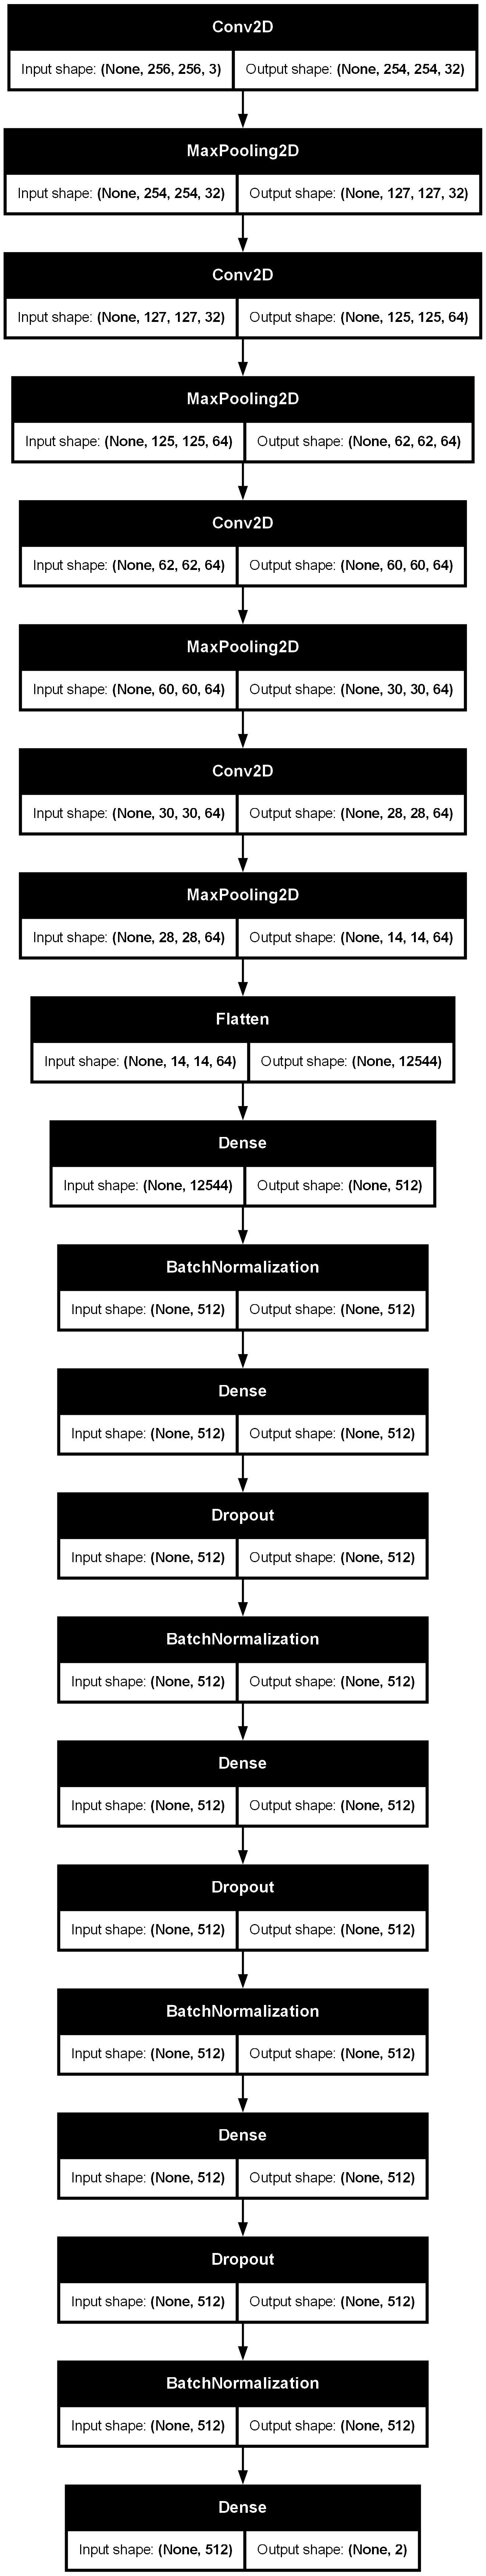

In [16]:
from tensorflow.keras.utils import plot_model
plot_model(model, show_shapes=True)

## Compile the Model:

In [18]:
model.compile(
    # specify the loss function to use during training
    loss='binary_crossentropy',
    # specify the optimizer algorithm to use during training
    optimizer='adam',
    # specify the evaluation metrics to use during training
    metrics=['accuracy']
)

## Train the model
Now we can train our model,  here we define epochs = 10, but you can perform hyperparameter tuning for better results.

In [19]:
history = model.fit(Train,
          epochs=10,
          validation_data=Validation)

Epoch 1/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 681s 4s/step - accuracy: 0.9222 - loss: 0.2539 - val_accuracy: 0.5625 - val_loss: 3.4216
Epoch 2/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 536s 3s/step - accuracy: 0.9528 - loss: 0.1536 - val_accuracy: 0.5000 - val_loss: 5.3335
Epoch 3/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 149s 912ms/step - accuracy: 0.9607 - loss: 0.1133 - val_accuracy: 0.5000 - val_loss: 33.5135
Epoch 4/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 167s 1s/step - accuracy: 0.9603 - loss: 0.1158 - val_accuracy: 0.5625 - val_loss: 1.6566
Epoch 5/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 173s 1s/step - accuracy: 0.9657 - loss: 0.1017 - val_accuracy: 0.5000 - val_loss: 3.9073
Epoch 6/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 173s 1s/step - accuracy: 0.9689 - loss: 0.0860 - val_accuracy: 0.6875 - val_loss: 0.5572
Epoch 7/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 160s 978ms/step - accuracy: 0.9716 - loss: 0.0846 - val_accuracy: 0.5000 - val_loss: 6.9188
Epoch 8/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 181s 1s/step - accuracy: 0.9653 - loss: 0.0967 - v

## Model Evaluation
Let’s visualize the training and validation accuracy with each epoch.

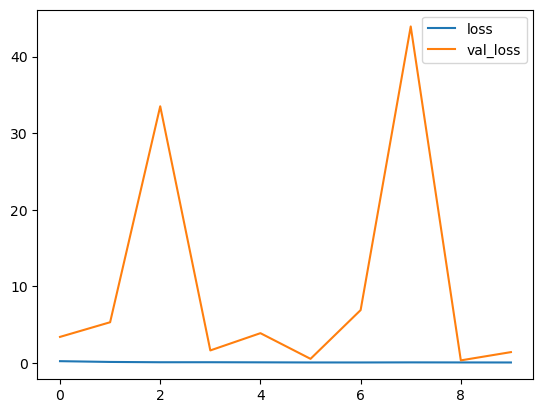

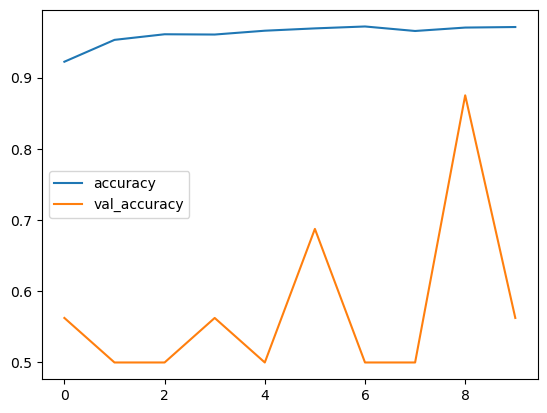

In [20]:
history_df = pd.DataFrame(history.history)
history_df.loc[:, ['loss', 'val_loss']].plot()
history_df.loc[:, ['accuracy', 'val_accuracy']].plot()
plt.show()

Our model is performing good on training dataset, but not on test dataset. So, this is the case of overfitting. This may be due to imbalanced dataset.

## Find the accuracy on Test Datasets

In [23]:
loss, accuracy = model.evaluate(Test)
print('The accuracy of the model on test dataset is',
      np.round(accuracy*100))

20/20 ━━━━━━━━━━━━━━━━━━━━ 5s 225ms/step - accuracy: 0.7147 - loss: 1.3517
The accuracy of the model on test dataset is 71.0


## Prediction
Let’s check the model for random images.

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 599ms/step
PNEUMONIA


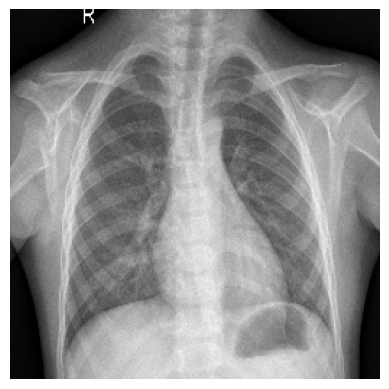

In [24]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

# Load image
test_image = tf.keras.utils.load_img(
    "chest_xray_data/chest_xray/test/NORMAL/IM-0010-0001.jpeg",
    target_size=(256, 256)
)

# Display image
plt.imshow(test_image)
plt.axis("off")

# Convert to array
test_image = tf.keras.utils.img_to_array(test_image)

# Normalize
test_image = test_image / 255.0

# Add batch dimension
test_image = np.expand_dims(test_image, axis=0)

# Predict
result = model.predict(test_image)

# Class probabilities
class_probabilities = result[0]

# Output label
if class_probabilities[0] > class_probabilities[1]:
    print("NORMAL")
else:
    print("PNEUMONIA")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step
Prediction: PNEUMONIA


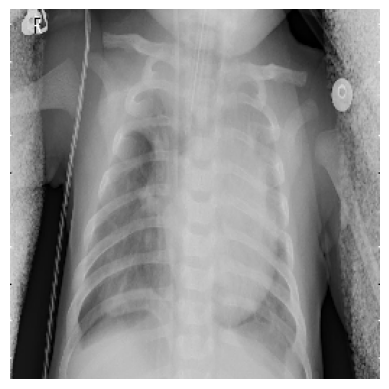

In [25]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

# Load image
test_image = tf.keras.utils.load_img(
    "chest_xray_data/chest_xray/test/PNEUMONIA/person100_bacteria_478.jpeg",
    target_size=(256, 256)
)

# Display image
plt.imshow(test_image)
plt.axis("off")

# Convert to array
test_image = tf.keras.utils.img_to_array(test_image)

# Normalize
test_image = test_image / 255.0

# Add batch dimension
test_image = np.expand_dims(test_image, axis=0)

# Predict
result = model.predict(test_image)

# Get predicted class
predicted_class = Train.class_names[np.argmax(result)]

print("Prediction:", predicted_class)

## Conclusion:
Our model is performing well but as per losses and accuracy curve per iterations. It is overfitting. This may be due to the unbalanced dataset. By balancing the dataset with an equal number of normal and pneumonia images. We can get a better result.